# KITTI Object Dataset Exploration

This notebook explores the KITTI object detection dataset stored locally. It follows the same lightweight style as the SemanticKITTI exploration work: first check the folder structure, then inspect images, labels, calibration files, and Velodyne point clouds.

This notebook does not use a PerceptionMetrics KITTI adapter because the repository does not currently include one. Instead, it reads the raw KITTI files directly.

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw


KITTI_ROOT = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI")


## Dataset Structure

The local KITTI folder contains the object dataset components:

- `data_object_image_2`: left color camera images
- `data_object_label_2`: object labels for the training split
- `data_object_calib`: camera/LiDAR calibration files
- `data_object_velodyne`: Velodyne point clouds

In [37]:
image_train_dir = KITTI_ROOT / "data_object_image_2" / "training" / "image_2"
image_test_dir = KITTI_ROOT / "data_object_image_2" / "testing" / "image_2"
label_train_dir = KITTI_ROOT / "data_object_label_2" / "training" / "label_2"
calib_train_dir = KITTI_ROOT / "data_object_calib" / "training" / "calib"
velodyne_train_dir = KITTI_ROOT / "data_object_velodyne" / "training" / "velodyne"

paths = {
    "train images": image_train_dir,
    "test images": image_test_dir,
    "train labels": label_train_dir,
    "train calib": calib_train_dir,
    "train velodyne": velodyne_train_dir,
}

for name, path in paths.items():
    print(f"{name:15s}: {path} -> {path.exists()}")

print("\nFile counts")
print("train images :", len(list(image_train_dir.glob("*.png"))))
print("test images  :", len(list(image_test_dir.glob("*.png"))))
print("train labels :", len(list(label_train_dir.glob("*.txt"))))
print("train calib  :", len(list(calib_train_dir.glob("*.txt"))))
print("train lidar  :", len(list(velodyne_train_dir.glob("*.bin"))))

train images   : /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_image_2/training/image_2 -> True
test images    : /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_image_2/testing/image_2 -> True
train labels   : /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_label_2/training/label_2 -> True
train calib    : /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_calib/training/calib -> True
train velodyne : /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_velodyne/training/velodyne -> True

File counts
train images : 7481
test images  : 7518
train labels : 7481
train calib  : 7481
train lidar  : 7481


In [38]:
sample_ids = sorted(path.stem for path in image_train_dir.glob("*.png"))
sample_id = sample_ids[10]
sample_id

'000010'

## KITTI Label Format

Each label row contains:

`type truncated occluded alpha bbox_left bbox_top bbox_right bbox_bottom height width length x y z rotation_y`

The 2D bounding box is in image pixel coordinates. The 3D location and dimensions are in camera coordinates.

In [39]:
KITTI_LABEL_COLUMNS = [
    "type",
    "truncated",
    "occluded",
    "alpha",
    "bbox_left",
    "bbox_top",
    "bbox_right",
    "bbox_bottom",
    "height",
    "width",
    "length",
    "x",
    "y",
    "z",
    "rotation_y",
]


def read_kitti_labels(label_path):
    rows = []
    with open(label_path, "r", encoding="utf-8") as label_file:
        for line in label_file:
            values = line.strip().split()
            if not values:
                continue
            row = [values[0]] + [float(value) for value in values[1:]]
            rows.append(row)
    return pd.DataFrame(rows, columns=KITTI_LABEL_COLUMNS)


labels = read_kitti_labels(label_train_dir / f"{sample_id}.txt")
labels

,type,truncated,occluded,alpha,bbox_left,bbox_top,bbox_right,bbox_bottom,height,width,length,x,y,z,rotation_y
0,Car,0.8,0.0,-2.09,1013.39,182.46,1241.00,374.00,1.57,1.65,3.35,4.43,1.65,5.20,-1.42
1,Car,0.0,0.0,1.95,354.43,185.52,549.52,294.49,1.43,1.70,3.95,-2.39,1.66,11.80,1.76
2,Pedestrian,0.0,2.0,1.41,859.54,159.80,879.68,221.40,1.96,0.72,1.09,8.33,1.55,23.51,1.75
3,Car,0.0,0.0,-1.78,819.63,178.12,926.85,251.56,1.51,1.60,3.24,5.85,1.64,16.50,-1.44
4,Car,0.0,2.0,-1.69,800.54,178.06,878.75,230.56,1.45,1.74,4.10,6.87,1.62,22.05,-1.39
5,Car,0.0,0.0,1.80,558.55,179.04,635.05,230.61,1.54,1.68,3.79,-0.38,1.76,23.64,1.78
6,Car,0.0,2.0,1.77,598.30,178.68,652.25,218.17,1.49,1.52,3.35,0.64,1.74,29.07,1.79
7,Car,0.0,1.0,-1.67,784.59,178.04,839.98,220.10,1.53,1.65,4.37,7.88,1.75,28.53,-1.40
8,Car,0.0,1.0,1.92,663.74,175.36,707.21,204.15,1.64,1.45,3.48,4.50,1.80,42.85,2.02
9,DontCare,-1.0,-1.0,-10.00,737.69,163.56,790.86,197.98,-1.00,-1.00,-1.00,-1000.00,-1000.00,-1000.00,-10.00


## Bounding Boxes per Frame

This counts how many annotation rows each training frame has. `DontCare` regions are counted separately because they are ignore regions, not object boxes to visualize as 3D boxes.

In [40]:
def count_boxes_per_frame(label_dir):
    rows = []
    for label_path in sorted(label_dir.glob("*.txt")):
        frame_labels = read_kitti_labels(label_path)
        real_labels = frame_labels[frame_labels["type"] != "DontCare"]
        rows.append(
            {
                "sample_id": label_path.stem,
                "total_rows": len(frame_labels),
                "object_boxes": len(real_labels),
                "dontcare_regions": int((frame_labels["type"] == "DontCare").sum()),
                "classes": ", ".join(sorted(real_labels["type"].unique())),
            }
        )
    return pd.DataFrame(rows)


box_counts = count_boxes_per_frame(label_train_dir)
box_counts.head(15)

,sample_id,total_rows,object_boxes,dontcare_regions,classes
0,000000,1,1,0,Pedestrian
1,000001,7,3,4,"Car, Cyclist, Truck"
2,000002,2,2,0,"Car, Misc"
3,000003,3,1,2,Car
4,000004,7,2,5,Car
5,000005,5,1,4,Pedestrian
6,000006,6,4,2,Car
7,000007,6,4,2,"Car, Cyclist"
8,000008,10,6,4,Car
9,000009,5,3,2,Car


In [41]:
print("Current sample:", sample_id)
box_counts[box_counts["sample_id"] == sample_id]

Current sample: 000010


,sample_id,total_rows,object_boxes,dontcare_regions,classes
10,000010,13,9,4,"Car, Pedestrian"


## Image and 2D Boxes

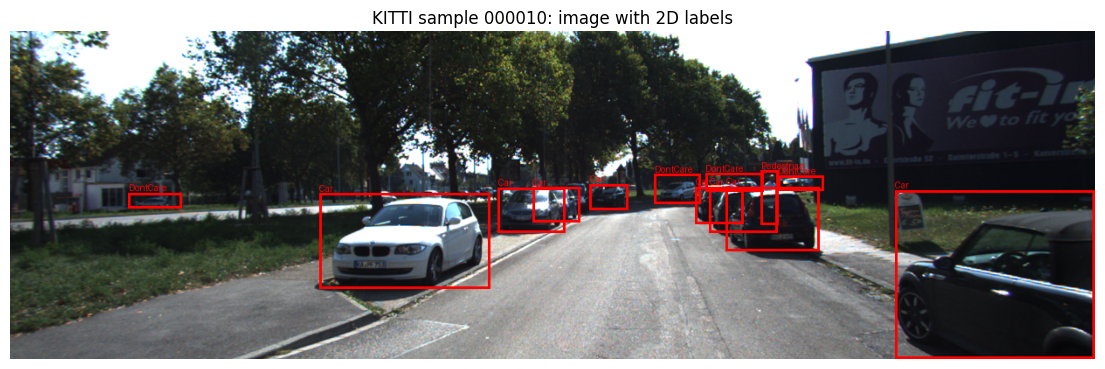

In [42]:
def draw_2d_boxes(image, labels):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for _, row in labels.iterrows():
        box = [row.bbox_left, row.bbox_top, row.bbox_right, row.bbox_bottom]
        draw.rectangle(box, outline="red", width=3)
        draw.text((row.bbox_left, max(0, row.bbox_top - 12)), row.type, fill="red")
    return image


image = Image.open(image_train_dir / f"{sample_id}.png").convert("RGB")
image_with_boxes = draw_2d_boxes(image, labels)

plt.figure(figsize=(14, 6))
plt.imshow(image_with_boxes)
plt.axis("off")
plt.title(f"KITTI sample {sample_id}: image with 2D labels")
plt.show()

## Velodyne Point Cloud

KITTI Velodyne files store each point as four `float32` values:

`x, y, z, intensity`

The coordinates are in the LiDAR coordinate frame and are measured in meters.

In [43]:
def read_velodyne_points(points_path):
    return np.fromfile(points_path, dtype=np.float32).reshape(-1, 4)


points = read_velodyne_points(velodyne_train_dir / f"{sample_id}.bin")
print("points shape:", points.shape)
print("xyz min:", points[:, :3].min(axis=0))
print("xyz max:", points[:, :3].max(axis=0))
print("intensity min/max:", points[:, 3].min(), points[:, 3].max())

points shape: (115875, 4)
xyz min: [-60.41  -68.254 -14.139]
xyz max: [78.356 61.635  2.912]
intensity min/max: 0.0 0.99


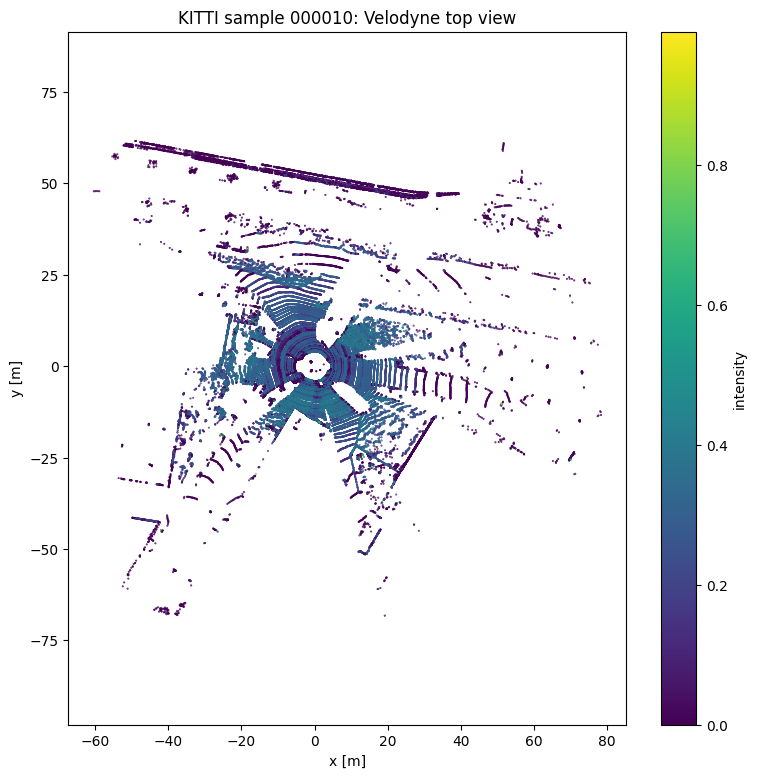

In [44]:
plt.figure(figsize=(9, 9))
plt.scatter(
    points[:, 0],
    points[:, 1],
    c=points[:, 3],
    s=0.2,
    cmap="viridis",
)
plt.colorbar(label="intensity")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"KITTI sample {sample_id}: Velodyne top view")
plt.show()

## Calibration and LiDAR Projection

KITTI calibration files contain projection matrices and transforms. To project Velodyne points into camera 2:

`image_points = P2 @ R0_rect @ Tr_velo_to_cam @ velodyne_points`

In [45]:
def read_calib(calib_path):
    calib = {}
    with open(calib_path, "r", encoding="utf-8") as calib_file:
        for line in calib_file:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, value = line.split(":", 1)
            calib[key] = np.array([float(v) for v in value.split()], dtype=np.float64)
    return calib


def calibration_matrices(calib):
    p2 = calib["P2"].reshape(3, 4)

    r0_rect = np.eye(4)
    r0_rect[:3, :3] = calib["R0_rect"].reshape(3, 3)

    tr_velo_to_cam = np.eye(4)
    tr_velo_to_cam[:3, :] = calib["Tr_velo_to_cam"].reshape(3, 4)

    return p2, r0_rect, tr_velo_to_cam


def project_velodyne_to_image(points, calib, image_size):
    p2, r0_rect, tr_velo_to_cam = calibration_matrices(calib)

    points_h = np.c_[points[:, :3], np.ones(len(points))]
    points_cam = (r0_rect @ tr_velo_to_cam @ points_h.T).T
    in_front = points_cam[:, 2] > 0

    points_img_h = (p2 @ points_cam.T).T
    points_img = points_img_h[:, :2] / points_img_h[:, 2:3]

    width, height = image_size
    in_image = (
        in_front
        & (points_img[:, 0] >= 0)
        & (points_img[:, 0] < width)
        & (points_img[:, 1] >= 0)
        & (points_img[:, 1] < height)
    )

    return points_img[in_image], points_cam[in_image, 2]


calib= read_calib(calib_train_dir / f"{sample_id}.txt")
projected_points, depths = project_velodyne_to_image(points, calib, image.size)
print("projected points:", projected_points.shape)

projected points: (16464, 2)


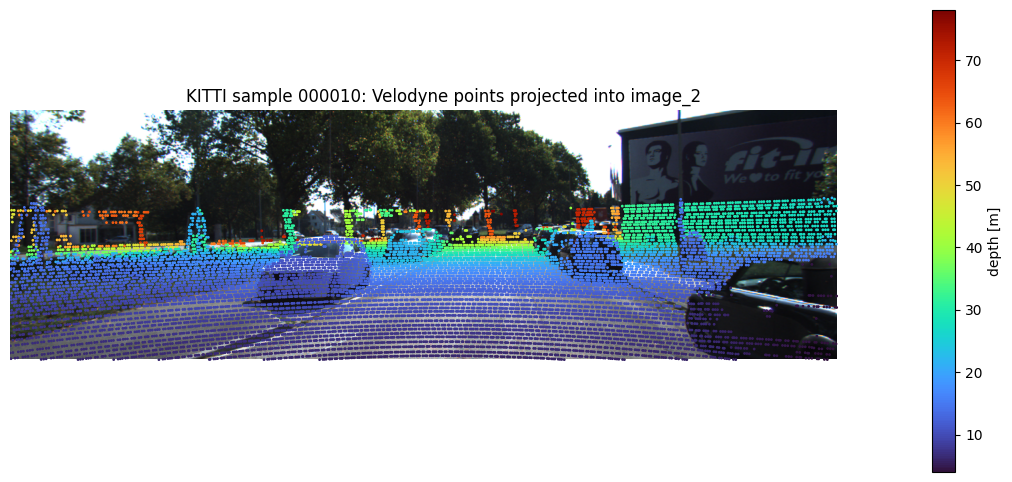

In [46]:
max_projected_points = 12000
if len(projected_points) > max_projected_points:
    indices = np.linspace(0, len(projected_points) - 1, max_projected_points, dtype=int)
    projected_points_plot = projected_points[indices]
    depths_plot = depths[indices]
else:
    projected_points_plot = projected_points
    depths_plot = depths

plt.figure(figsize=(14, 6))
plt.imshow(image)
plt.scatter(
    projected_points_plot[:, 0],
    projected_points_plot[:, 1],
    c=depths_plot,
    s=1.0,
    cmap="turbo",
)
plt.colorbar(label="depth [m]")
plt.axis("off")
plt.title(f"KITTI sample {sample_id}: Velodyne points projected into image_2")
plt.show()

## MMDetection3D One-Sample Inference

MMDetection3D's LiDAR detection inferencer can run directly on one KITTI `.bin` point cloud. For LiDAR-only models such as PointPillars or SECOND, the point cloud file is the main input. The image and calibration paths are kept here for reference and for later camera/LiDAR visualization.

In [47]:
MMDET3D_ROOT = Path("/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/external/mmdetection3d")

mmdet3d_sample = {
    "sample_id": sample_id,
    "points": str(velodyne_train_dir / f"{sample_id}.bin"),
    "image": str(image_train_dir / f"{sample_id}.png"),
    "calib": str(calib_train_dir / f"{sample_id}.txt"),
    "label": str(label_train_dir / f"{sample_id}.txt"),
}

mmdet3d_sample

{'sample_id': '000010',
 'points': '/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_velodyne/training/velodyne/000010.bin',
 'image': '/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_image_2/training/image_2/000010.png',
 'calib': '/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_calib/training/calib/000010.txt',
 'label': '/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/KITTI/data_object_label_2/training/label_2/000010.txt'}

In [48]:
from mmdet3d.apis import LidarDet3DInferencer

mmdet3d_config_path = MMDET3D_ROOT / "configs/pointpillars/pointpillars_hv_secfpn_8xb6-160e_kitti-3d-3class.py"

# Update this after downloading the matching checkpoint.
mmdet3d_checkpoint_path = MMDET3D_ROOT / "checkpoints/pointpillars_kitti_3class.pth"
print("config exists:", mmdet3d_config_path.exists(), mmdet3d_config_path)
print("checkpoint exists:", mmdet3d_checkpoint_path.exists(), mmdet3d_checkpoint_path)

config exists: True /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/external/mmdetection3d/configs/pointpillars/pointpillars_hv_secfpn_8xb6-160e_kitti-3d-3class.py
checkpoint exists: True /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/external/mmdetection3d/checkpoints/pointpillars_kitti_3class.pth


In [49]:
if not mmdet3d_config_path.exists():
    raise FileNotFoundError(mmdet3d_config_path)

if not mmdet3d_checkpoint_path.exists():
    raise FileNotFoundError(
        "Set `mmdet3d_checkpoint_path` to a downloaded checkpoint before running inference."
    )

inferencer = LidarDet3DInferencer(
    model=str(mmdet3d_config_path),
    weights=str(mmdet3d_checkpoint_path),
    device="cuda:0",
)

mmdet3d_result = inferencer(
    inputs={"points": mmdet3d_sample["points"]},
    pred_score_thr=0.3,
    show=False,
    no_save_vis=True,
    no_save_pred=True,
)

mmdet3d_prediction = mmdet3d_result["predictions"][0]
print("predicted boxes:", len(mmdet3d_prediction.get("bboxes_3d", [])))
mmdet3d_prediction.keys()

Output()

Loads checkpoint by local backend from path: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/external/mmdetection3d/checkpoints/pointpillars_kitti_3class.pth


/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


predicted boxes: 12


dict_keys(['labels_3d', 'scores_3d', 'bboxes_3d', 'box_type_3d'])

In [50]:
if "mmdet3d_prediction" in globals():
    pred_boxes = np.asarray(mmdet3d_prediction["bboxes_3d"], dtype=np.float32)
    pred_labels = np.asarray(mmdet3d_prediction["labels_3d"], dtype=np.int64)
    pred_scores = np.asarray(mmdet3d_prediction["scores_3d"], dtype=np.float32)

    pd.DataFrame(
        {
            "label": pred_labels,
            "score": pred_scores,
            "x": pred_boxes[:, 0],
            "y": pred_boxes[:, 1],
            "z": pred_boxes[:, 2],
            "dx": pred_boxes[:, 3],
            "dy": pred_boxes[:, 4],
            "dz": pred_boxes[:, 5],
            "yaw": pred_boxes[:, 6],
        }
    ).sort_values("score", ascending=False).head(20)


## BEV Plot

This gives a simple bird's-eye-view plot of the Velodyne point cloud. Ground-truth boxes are drawn from the KITTI labels, while prediction boxes are drawn from `mmdet3d_prediction` if the inference cell has been run.

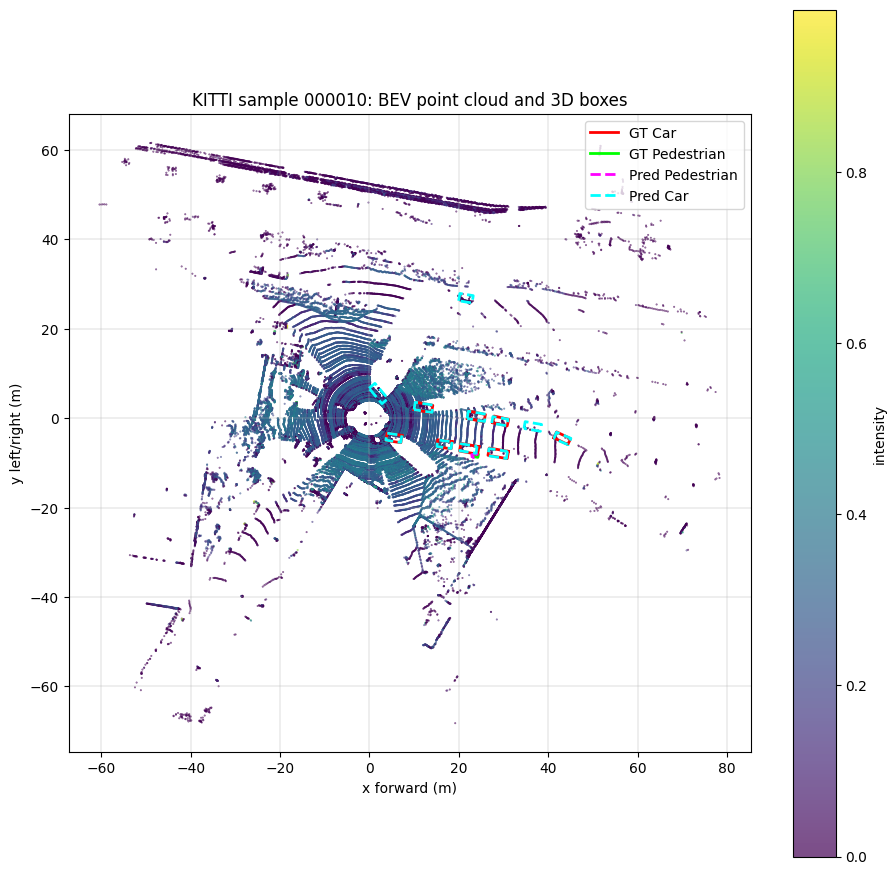

In [51]:
BEV_CLASS_COLORS = {
    "Car": "red",
    "Van": "orange",
    "Truck": "gold",
    "Pedestrian": "lime",
    "Person_sitting": "limegreen",
    "Cyclist": "deepskyblue",
    "Tram": "violet",
    "Misc": "white",
}

BEV_PRED_CLASS_COLORS = {
    "Car": "cyan",
    "Pedestrian": "magenta",
    "Cyclist": "yellow",
}

MMDET3D_KITTI_CLASSES = ["Pedestrian", "Cyclist", "Car"]


def kitti_box_corners_camera(row):
    h, w, l = row.height, row.width, row.length
    x, y, z = row.x, row.y, row.z
    ry = row.rotation_y

    x_corners = [l / 2, l / 2, -l / 2, -l / 2, l / 2, l / 2, -l / 2, -l / 2]
    y_corners = [0, 0, 0, 0, -h, -h, -h, -h]
    z_corners = [w / 2, -w / 2, -w / 2, w / 2, w / 2, -w / 2, -w / 2, w / 2]

    rotation = np.array(
        [
            [np.cos(ry), 0, np.sin(ry)],
            [0, 1, 0],
            [-np.sin(ry), 0, np.cos(ry)],
        ]
    )
    corners = rotation @ np.vstack([x_corners, y_corners, z_corners])
    corners += np.array([[x], [y], [z]])
    return corners.T


def camera_to_velodyne(points_cam, calib):
    _, r0_rect, tr_velo_to_cam = calibration_matrices(calib)
    points_h = np.c_[points_cam, np.ones(len(points_cam))]
    velo_from_cam = np.linalg.inv(r0_rect @ tr_velo_to_cam)
    return (velo_from_cam @ points_h.T).T[:, :3]


def lidar_box_corners(box):
    x, y, z, dx, dy, dz, yaw = box[:7]

    x_corners = [dx / 2, dx / 2, -dx / 2, -dx / 2, dx / 2, dx / 2, -dx / 2, -dx / 2]
    y_corners = [dy / 2, -dy / 2, -dy / 2, dy / 2, dy / 2, -dy / 2, -dy / 2, dy / 2]
    z_corners = [0, 0, 0, 0, dz, dz, dz, dz]

    rotation = np.array(
        [
            [np.cos(yaw), -np.sin(yaw), 0],
            [np.sin(yaw), np.cos(yaw), 0],
            [0, 0, 1],
        ]
    )
    corners = rotation @ np.vstack([x_corners, y_corners, z_corners])
    corners += np.array([[x], [y], [z]])
    return corners.T


def plot_bev_box(ax, corners, color, label=None, linestyle="-"):
    bottom = corners[:4, :2]
    closed = np.vstack([bottom, bottom[0]])
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=2, linestyle=linestyle, label=label)


def plot_kitti_bev(points, labels, calib, prediction=None, score_threshold=0.3, max_points=120000):
    if len(points) > max_points:
        indices = np.linspace(0, len(points) - 1, max_points, dtype=int)
        points_to_plot = points[indices]
    else:
        points_to_plot = points

    fig, ax = plt.subplots(figsize=(11, 11))
    scatter = ax.scatter(
        points_to_plot[:, 0],
        points_to_plot[:, 1],
        c=points_to_plot[:, 3],
        s=0.2,
        cmap="viridis",
        alpha=0.7,
    )
    plt.colorbar(scatter, ax=ax, label="intensity")

    used_labels = set()
    for _, row in labels.iterrows():
        if row.type == "DontCare":
            continue
        corners_cam = kitti_box_corners_camera(row)
        corners_velo = camera_to_velodyne(corners_cam, calib)
        class_name = row.type
        legend_label = f"GT {class_name}" if class_name not in used_labels else None
        plot_bev_box(
            ax,
            corners_velo,
            BEV_CLASS_COLORS.get(class_name, "white"),
            label=legend_label,
        )
        used_labels.add(class_name)

    if prediction is not None:
        pred_boxes = np.asarray(prediction.get("bboxes_3d", []), dtype=np.float32)
        pred_labels = np.asarray(prediction.get("labels_3d", []), dtype=np.int64)
        pred_scores = np.asarray(prediction.get("scores_3d", []), dtype=np.float32)
        used_pred_labels = set()

        for box, label_idx, score in zip(pred_boxes, pred_labels, pred_scores):
            if score < score_threshold:
                continue
            class_name = MMDET3D_KITTI_CLASSES[int(label_idx)]
            legend_label = f"Pred {class_name}" if class_name not in used_pred_labels else None
            plot_bev_box(
                ax,
                lidar_box_corners(box),
                BEV_PRED_CLASS_COLORS.get(class_name, "cyan"),
                label=legend_label,
                linestyle="--",
            )
            used_pred_labels.add(class_name)

    ax.set_xlabel("x forward (m)")
    ax.set_ylabel("y left/right (m)")
    ax.set_title(f"KITTI sample {sample_id}: BEV point cloud and 3D boxes")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linewidth=0.3)
    ax.legend(loc="upper right")
    plt.show()


plot_kitti_bev(
    points,
    labels,
    calib,
    prediction=globals().get("mmdet3d_prediction"),
    score_threshold=0.3,
)



## Open3D / OpenGL 3D Viewer

KITTI 3D ground-truth boxes are stored in camera coordinates. For a LiDAR viewer, the corners are first created in camera coordinates and then transformed back into the Velodyne frame using the calibration matrices. MMDetection3D predictions are already returned in LiDAR coordinates, so they can be drawn directly.

This opens an Open3D window. Close the window to return control to the notebook.

In [52]:
try:
    import open3d as o3d
except ImportError as exc:
    raise ImportError("Install Open3D with `pip install open3d` to run this section.") from exc


BOX_LINES = [
    [0, 1], [1, 2], [2, 3], [3, 0],
    [4, 5], [5, 6], [6, 7], [7, 4],
    [0, 4], [1, 5], [2, 6], [3, 7],
]

CLASS_COLORS = {
    "Car": [1.0, 0.0, 0.0],
    "Van": [1.0, 0.5, 0.0],
    "Truck": [1.0, 0.8, 0.0],
    "Pedestrian": [0.0, 1.0, 0.0],
    "Person_sitting": [0.3, 1.0, 0.3],
    "Cyclist": [0.0, 0.5, 1.0],
    "Tram": [0.8, 0.0, 1.0],
    "Misc": [1.0, 1.0, 1.0],
}

PRED_CLASS_COLORS = {
    "Car": [0.0, 1.0, 1.0],
    "Pedestrian": [1.0, 0.0, 1.0],
    "Cyclist": [1.0, 1.0, 0.0],
}

MMDET3D_KITTI_CLASSES = ["Pedestrian", "Cyclist", "Car"]


def intensity_colors(intensity):
    intensity = np.asarray(intensity, dtype=np.float32)
    low, high = np.percentile(intensity, [1, 99])
    scaled = np.clip((intensity - low) / max(high - low, 1e-6), 0.0, 1.0)
    return plt.cm.viridis(scaled)[:, :3]


def kitti_box_corners_camera(row):
    h, w, l = row.height, row.width, row.length
    x, y, z = row.x, row.y, row.z
    ry = row.rotation_y

    x_corners = [l / 2, l / 2, -l / 2, -l / 2, l / 2, l / 2, -l / 2, -l / 2]
    y_corners = [0, 0, 0, 0, -h, -h, -h, -h]
    z_corners = [w / 2, -w / 2, -w / 2, w / 2, w / 2, -w / 2, -w / 2, w / 2]

    rotation = np.array(
        [
            [np.cos(ry), 0, np.sin(ry)],
            [0, 1, 0],
            [-np.sin(ry), 0, np.cos(ry)],
        ]
    )
    corners = rotation @ np.vstack([x_corners, y_corners, z_corners])
    corners += np.array([[x], [y], [z]])
    return corners.T


def lidar_box_corners(box):
    x, y, z, dx, dy, dz, yaw = box[:7]

    x_corners = [dx / 2, dx / 2, -dx / 2, -dx / 2, dx / 2, dx / 2, -dx / 2, -dx / 2]
    y_corners = [dy / 2, -dy / 2, -dy / 2, dy / 2, dy / 2, -dy / 2, -dy / 2, dy / 2]
    z_corners = [0, 0, 0, 0, dz, dz, dz, dz]

    rotation = np.array(
        [
            [np.cos(yaw), -np.sin(yaw), 0],
            [np.sin(yaw), np.cos(yaw), 0],
            [0, 0, 1],
        ]
    )
    corners = rotation @ np.vstack([x_corners, y_corners, z_corners])
    corners += np.array([[x], [y], [z]])
    return corners.T


def camera_to_velodyne(points_cam, calib):
    _, r0_rect, tr_velo_to_cam = calibration_matrices(calib)
    points_h = np.c_[points_cam, np.ones(len(points_cam))]
    velo_from_cam = np.linalg.inv(r0_rect @ tr_velo_to_cam)
    return (velo_from_cam @ points_h.T).T[:, :3]


def bbox_lineset(corners, color):
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(corners)
    line_set.lines = o3d.utility.Vector2iVector(BOX_LINES)
    line_set.colors = o3d.utility.Vector3dVector([color] * len(BOX_LINES))
    return line_set


def make_open3d_scene(
    points,
    labels,
    calib,
    prediction=None,
    box_mode="both",
    score_threshold=0.3,
    max_points=100000,
):
    if len(points) > max_points:
        indices = np.linspace(0, len(points) - 1, max_points, dtype=int)
        points = points[indices]

    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(points[:, :3])
    point_cloud.colors = o3d.utility.Vector3dVector(intensity_colors(points[:, 3]))

    geometries = [point_cloud, o3d.geometry.TriangleMesh.create_coordinate_frame(size=3.0)]

    if box_mode in {"ground_truth", "both"}:
        for _, row in labels.iterrows():
            if row.type == "DontCare":
                continue
            corners_cam = kitti_box_corners_camera(row)
            corners_velo = camera_to_velodyne(corners_cam, calib)
            color = CLASS_COLORS.get(row.type, [1.0, 1.0, 1.0])
            geometries.append(bbox_lineset(corners_velo, color))

    if box_mode in {"predictions", "both"} and prediction is not None:
        pred_boxes = np.asarray(prediction.get("bboxes_3d", []), dtype=np.float32)
        pred_labels = np.asarray(prediction.get("labels_3d", []), dtype=np.int64)
        pred_scores = np.asarray(prediction.get("scores_3d", []), dtype=np.float32)

        for box, label_idx, score in zip(pred_boxes, pred_labels, pred_scores):
            if score < score_threshold:
                continue
            class_name = MMDET3D_KITTI_CLASSES[int(label_idx)]
            color = PRED_CLASS_COLORS.get(class_name, [0.0, 1.0, 1.0])
            geometries.append(bbox_lineset(lidar_box_corners(box), color))

    return geometries


box_mode = "both"  # choose: "ground_truth", "predictions", or "both"
prediction = globals().get("mmdet3d_prediction")

geometries = make_open3d_scene(
    points,
    labels,
    calib,
    prediction=prediction,
    box_mode=box_mode,
    score_threshold=0.3,
)
o3d.visualization.draw_geometries(geometries, window_name=f"KITTI sample {sample_id}")

# nuScenes Mini Exploration

This section explores the local nuScenes mini dataset using the official `nuscenes-devkit`. Unlike KITTI, nuScenes stores most metadata in JSON tables and connects sensors, ego poses, calibrated sensors, samples, and annotations through tokens.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import BoxVisibility


NUSCENES_ROOT = Path(
    "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/nuScenes/v1.0-mini"
)

nusc = NuScenes(version="v1.0-mini", dataroot=str(NUSCENES_ROOT), verbose=True)



Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.342 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


## nuScenes Dataset Summary

The mini split contains a small number of scenes, but it still has all the main nuScenes tables: scenes, samples, sample data, calibrated sensors, ego poses, annotations, categories, and maps.


In [5]:
from collections import Counter

category_counts = Counter(
    nusc.get("category", nusc.get("instance", ann["instance_token"])["category_token"])["name"]
    for ann in nusc.sample_annotation
)

print("Scenes:", len(nusc.scene))
print("Samples:", len(nusc.sample))
print("Sample annotations:", len(nusc.sample_annotation))




Scenes: 10
Samples: 404
Sample annotations: 18538


## Select a nuScenes Sample

Each nuScenes `sample` links one timestamp across the available sensors. The `data` field contains tokens for cameras, LiDAR, and radars. The `anns` field contains annotation tokens for that sample.


In [6]:
scene_idx = 0
scene = nusc.scene[scene_idx]
sample_token = scene["first_sample_token"]
sample = nusc.get("sample", sample_token)

print("Scene:", scene["name"])
print("Description:", scene["description"])
print("Sample token:", sample_token)
print("Timestamp:", sample["timestamp"])
print("Sensors:", sorted(sample["data"].keys()))
print("Annotations in sample:", len(sample["anns"]))



Scene: scene-0061
Description: Parked truck, construction, intersection, turn left, following a van
Sample token: ca9a282c9e77460f8360f564131a8af5
Timestamp: 1532402927647951
Sensors: ['CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT', 'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 'LIDAR_TOP', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT']
Annotations in sample: 69


In [7]:
rows = []
for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)
    instance = nusc.get("instance", ann["instance_token"])
    category = nusc.get("category", instance["category_token"])
    rows.append(
        {
            "category": category["name"],
            "translation_x": ann["translation"][0],
            "translation_y": ann["translation"][1],
            "translation_z": ann["translation"][2],
            "width": ann["size"][0],
            "length": ann["size"][1],
            "height": ann["size"][2],
            "num_lidar_pts": ann["num_lidar_pts"],
            "num_radar_pts": ann["num_radar_pts"],
            "visibility_token": ann["visibility_token"],
        }
    )

pd.DataFrame(rows).sort_values("num_lidar_pts", ascending=False)



,category,translation_x,translation_y,translation_z,width,length,height,num_lidar_pts,num_radar_pts,visibility_token
18,vehicle.truck,409.989,1164.099,1.623,2.877,10.201,3.595,495,13,4
10,movable_object.barrier,408.524,1190.723,0.733,1.910,0.555,1.055,77,0,4
41,movable_object.barrier,400.519,1171.691,0.594,2.073,0.633,1.078,50,0,4
7,vehicle.car,409.132,1201.516,1.010,1.837,4.320,1.631,45,6,4
63,movable_object.barrier,399.285,1171.936,0.558,2.126,0.716,1.031,32,0,3
...,...,...,...,...,...,...,...,...,...,...
13,human.pedestrian.adult,356.068,1144.504,0.820,0.800,0.908,1.835,1,0,4
56,human.pedestrian.adult,390.721,1120.160,0.880,0.728,0.858,2.000,1,0,4
30,human.pedestrian.adult,410.519,1166.187,2.295,0.708,0.863,1.616,0,0,1
46,human.pedestrian.adult,390.311,1121.642,0.818,0.759,0.837,1.916,0,0,4


## Front Camera with 3D Boxes




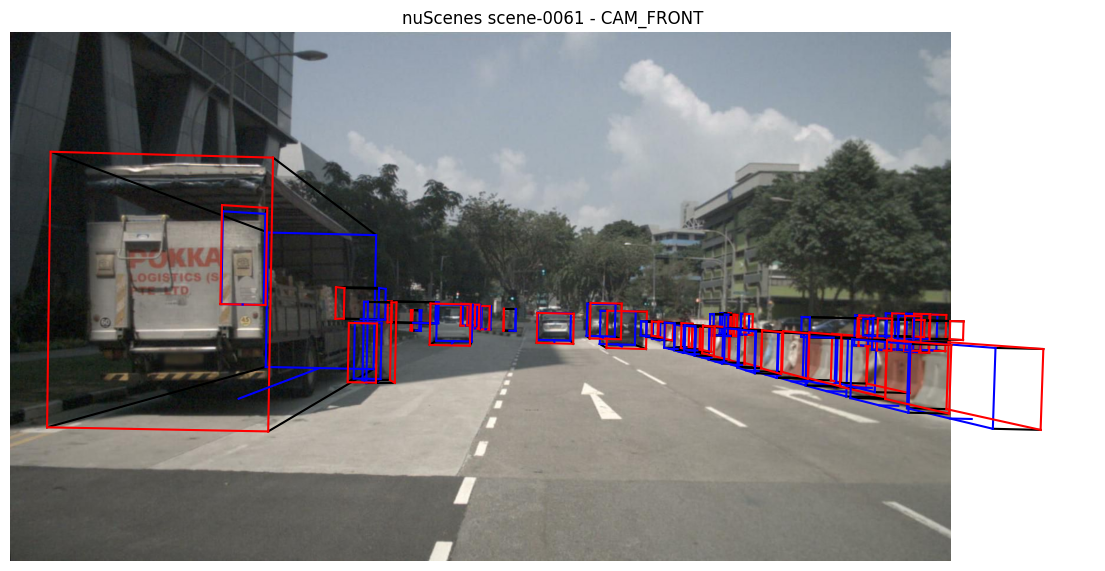

camera image: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/nuScenes/v1.0-mini/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
visible boxes: 48


In [8]:
camera_channel = "CAM_FRONT"
cam_token = sample["data"][camera_channel]
cam_path, cam_boxes, cam_intrinsic = nusc.get_sample_data(
    cam_token, box_vis_level=BoxVisibility.ANY
)

image = Image.open(cam_path).convert("RGB")

plt.figure(figsize=(14, 8))
ax = plt.gca()
ax.imshow(image)
for box in cam_boxes:
    box.render(ax, view=np.asarray(cam_intrinsic), normalize=True, linewidth=1.5)
ax.set_title(f"nuScenes {scene['name']} - {camera_channel}")
ax.axis("off")
plt.show()

print("camera image:", cam_path)
print("visible boxes:", len(cam_boxes))



## LiDAR BEV with 3D Boxes


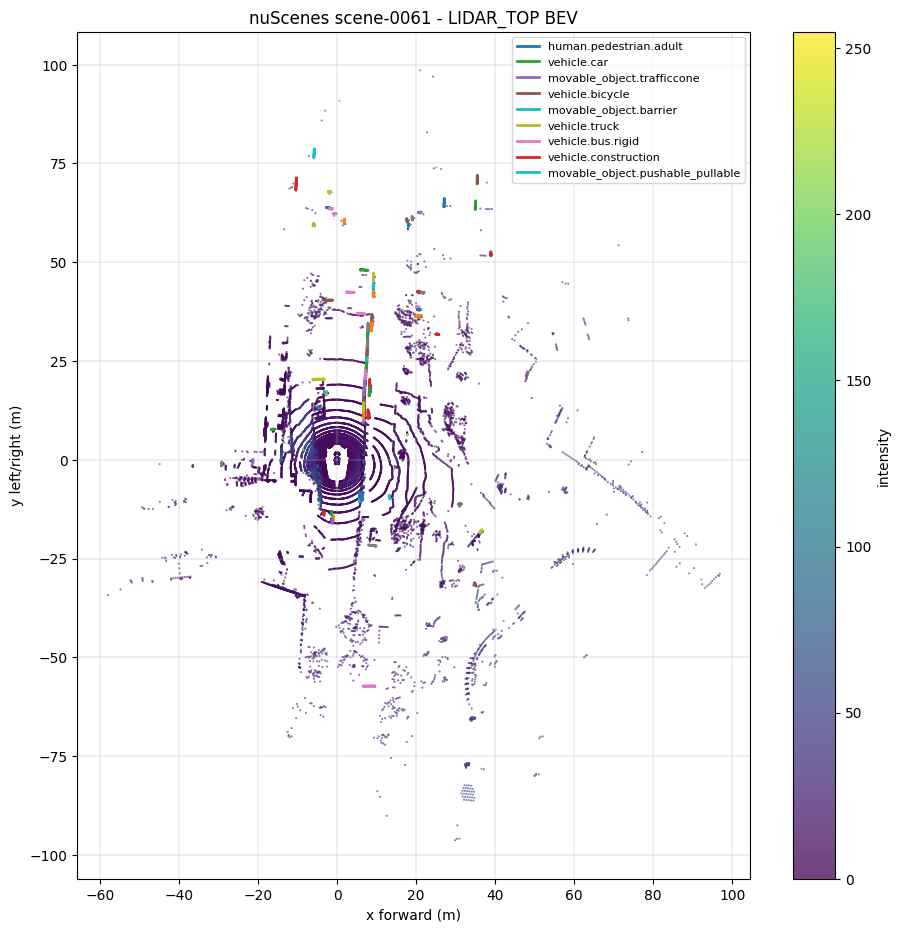

lidar file: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/nuScenes/v1.0-mini/samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin
points: (34688, 4)
boxes: 69


In [6]:
def plot_nuscenes_bev(sample, lidar_channel="LIDAR_TOP", max_points=120000):
    lidar_token = sample["data"][lidar_channel]
    lidar_path, lidar_boxes, _ = nusc.get_sample_data(lidar_token)
    point_cloud = LidarPointCloud.from_file(lidar_path)
    points = point_cloud.points.T

    if len(points) > max_points:
        indices = np.linspace(0, len(points) - 1, max_points, dtype=int)
        points_to_plot = points[indices]
    else:
        points_to_plot = points

    fig, ax = plt.subplots(figsize=(11, 11))
    scatter = ax.scatter(
        points_to_plot[:, 0],
        points_to_plot[:, 1],
        c=points_to_plot[:, 3],
        s=0.2,
        cmap="viridis",
        alpha=0.75,
    )
    plt.colorbar(scatter, ax=ax, label="intensity")

    used_categories = set()
    for box in lidar_boxes:
        corners = box.corners().T
        bottom = corners[:4, :2]
        closed = np.vstack([bottom, bottom[0]])
        category = box.name
        label = category if category not in used_categories else None
        ax.plot(closed[:, 0], closed[:, 1], linewidth=2, label=label)
        used_categories.add(category)

    ax.set_xlabel("x forward (m)")
    ax.set_ylabel("y left/right (m)")
    ax.set_title(f"nuScenes {scene['name']} - {lidar_channel} BEV")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linewidth=0.3)
    if used_categories:
        ax.legend(loc="upper right", fontsize=8)
    plt.show()

    print("lidar file:", lidar_path)
    print("points:", points.shape)
    print("boxes:", len(lidar_boxes))


plot_nuscenes_bev(sample)



## nuScenes 3D LiDAR Viewer

.


In [11]:
try:
    import open3d as o3d
except ImportError as exc:
    raise ImportError("Install Open3D with `pip install open3d` to run this section.") from exc


NUSCENES_BOX_LINES = [
    [0, 1], [1, 2], [2, 3], [3, 0],
    [4, 5], [5, 6], [6, 7], [7, 4],
    [0, 4], [1, 5], [2, 6], [3, 7],
]

NUSCENES_CATEGORY_COLORS = {
    "vehicle.car": [1.0, 0.0, 0.0],
    "vehicle.truck": [1.0, 0.5, 0.0],
    "vehicle.bus.rigid": [1.0, 0.8, 0.0],
    "vehicle.bus.bendy": [1.0, 0.8, 0.0],
    "vehicle.motorcycle": [0.0, 0.5, 1.0],
    "vehicle.bicycle": [0.0, 1.0, 1.0],
    "human.pedestrian.adult": [0.0, 1.0, 0.0],
    "human.pedestrian.child": [0.3, 1.0, 0.3],
    "movable_object.barrier": [1.0, 0.0, 1.0],
    "movable_object.trafficcone": [1.0, 1.0, 0.0],
}


def nuscenes_intensity_colors(intensity):
    intensity = np.asarray(intensity, dtype=np.float32)
    low, high = np.percentile(intensity, [1, 99])
    scaled = np.clip((intensity - low) / max(high - low, 1e-6), 0.0, 1.0)
    return plt.cm.viridis(scaled)[:, :3]


def nuscenes_box_lineset(box, color):
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(box.corners().T)
    line_set.lines = o3d.utility.Vector2iVector(NUSCENES_BOX_LINES)
    line_set.colors = o3d.utility.Vector3dVector([color] * len(NUSCENES_BOX_LINES))
    return line_set


def make_nuscenes_open3d_scene(sample, lidar_channel="LIDAR_TOP", max_points=120000):
    lidar_token = sample["data"][lidar_channel]
    lidar_path, lidar_boxes, _ = nusc.get_sample_data(lidar_token)
    point_cloud_data = LidarPointCloud.from_file(lidar_path).points.T

    if len(point_cloud_data) > max_points:
        indices = np.linspace(0, len(point_cloud_data) - 1, max_points, dtype=int)
        point_cloud_data = point_cloud_data[indices]

    point_cloud = o3d.geometry.PointCloud()
    point_cloud.points = o3d.utility.Vector3dVector(point_cloud_data[:, :3])
    point_cloud.colors = o3d.utility.Vector3dVector(
        nuscenes_intensity_colors(point_cloud_data[:, 3])
    )

    geometries = [
        point_cloud,
        o3d.geometry.TriangleMesh.create_coordinate_frame(size=3.0),
    ]

    for box in lidar_boxes:
        print (box)
        color = NUSCENES_CATEGORY_COLORS.get(box.name, [1.0, 1.0, 1.0])
        geometries.append(nuscenes_box_lineset(box, color))

    return geometries


geometries = make_nuscenes_open3d_scene(sample)
o3d.visualization.draw_geometries(
    geometries,
    window_name=f"nuScenes {scene['name']} LIDAR_TOP",
)



label: nan, score: nan, xyz: [18.41, 59.52, 0.77], wlh: [0.62, 0.67, 1.64], rot axis: [0.01, -0.02, 1.00], ang(degrees): 179.02, ang(rad): 3.12, vel: nan, nan, nan, name: human.pedestrian.adult, token: ef63a697930c4b20a6b9791f423351da
label: nan, score: nan, xyz: [21.00, 36.06, -0.03], wlh: [0.78, 0.77, 1.71], rot axis: [-0.03, 0.01, -1.00], ang(degrees): -87.24, ang(rad): -1.52, vel: nan, nan, nan, name: human.pedestrian.adult, token: 6b89da9bf1f84fd6a5fbe1c3b236f809
label: nan, score: nan, xyz: [37.35, 64.40, 0.45], wlh: [2.01, 4.63, 1.57], rot axis: [0.01, -0.02, 1.00], ang(degrees): 176.99, ang(rad): 3.09, vel: nan, nan, nan, name: vehicle.car, token: 924ee6ac1fed440a9d9e3720aac635a0
label: nan, score: nan, xyz: [25.37, 32.17, -0.16], wlh: [0.75, 0.82, 1.64], rot axis: [-0.01, -0.02, 1.00], ang(degrees): -95.14, ang(rad): -1.66, vel: nan, nan, nan, name: human.pedestrian.adult, token: 91e3608f55174a319246f361690906ba
label: nan, score: nan, xyz: [6.63, -15.39, -1.82], wlh: [0.43, 0

## nuScenes Annotation Table for the Selected Sample
